<a href="https://colab.research.google.com/github/Ariel-Pineapple/qc-anomaly-detection-isolation-forest/blob/main/04_model_isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

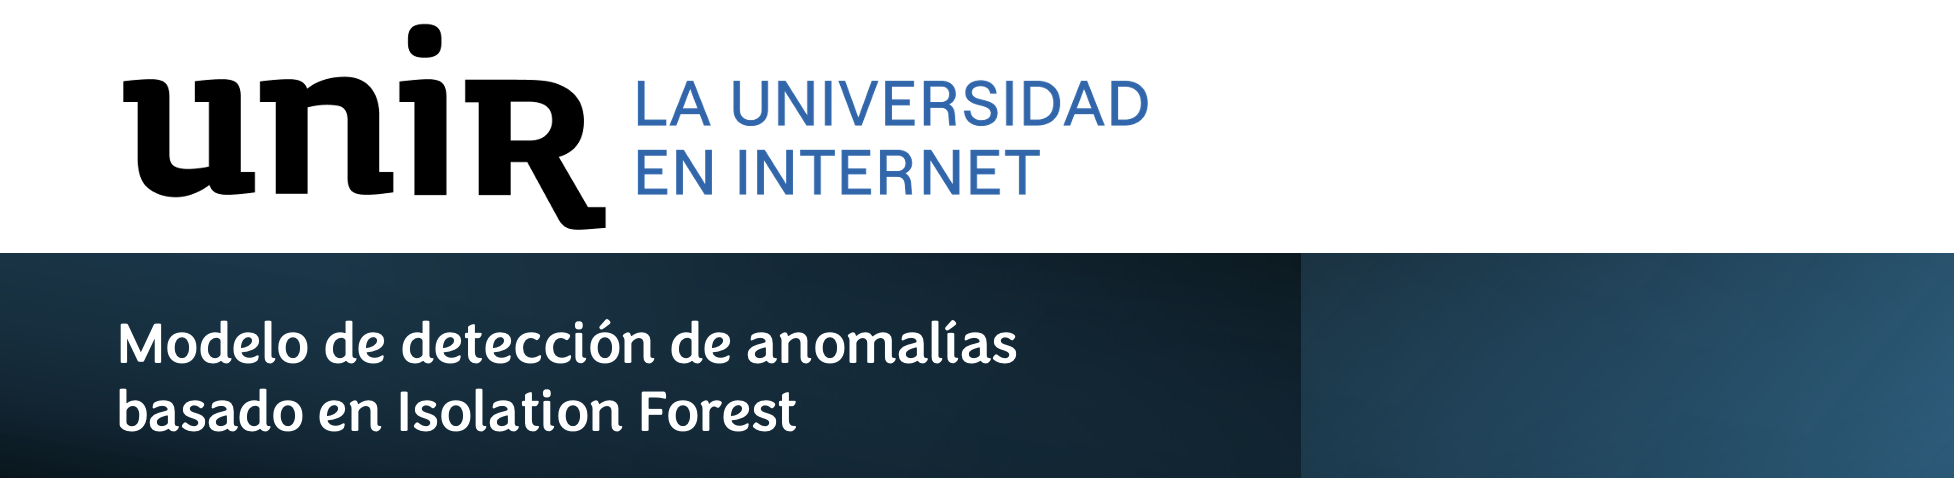

# Modelo de detección de anomalías basado en Isolation Forest

## Objetivo

Entrenar un modelo no supervisado basado en Isolation Forest para detectar anomalías en datos de control de calidad, y comparar su desempeño contra el baseline estadístico basado en reglas de Westgard.

## Enfoque

El modelo se entrena sobre variables derivadas (feature engineering) que capturan:
- Nivel del proceso
- Variabilidad
- Cambios temporales
- Persistencia de anomalías

## Hipótesis

Se espera que el modelo basado en Isolation Forest mejore la sensibilidad en la detección de anomalías, aceptando como posible compensación un incremento moderado en la tasa de falsas alarmas frente al baseline estadístico.

# Detección de anomalías con Isolation Forest en control de calidad

Este notebook implementa un modelo de detección de anomalías basado en Isolation Forest sobre datos sintéticos de control de calidad en inmunoensayos.

Se evalúa su desempeño frente a un baseline estadístico (Reglas de Westgard), utilizando métricas de recall y tasa de falsas alarmas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme()
pd.set_option("display.max_columns", None)

## 1. Carga del dataset enriquecido

Se utiliza el dataset generado en la etapa de feature engineering.

In [2]:
df = pd.read_csv("dataset_qc_features.csv")
df["fecha"] = pd.to_datetime(df["fecha"])

df.head()

,id_registro,fecha,analito,lote,equipo,sco,estado_real,tipo_drift,rolling_mean_5,delta,drift,rolling_std_5,zscore_dynamic,alert_2s,rolling_alerts_5,pct_change
0,5,2025-01-05,VIH,L001,E01,0.9883,0,normal,1.02296,-0.0879,-0.03466,0.035426,-0.978385,0,0.0,-0.081676
1,6,2025-01-06,VIH,L001,E01,0.9883,0,normal,1.01566,0.0000,-0.02736,0.038573,-0.709310,0,0.0,0.000000
2,7,2025-01-07,VIH,L001,E01,1.0790,0,normal,1.03284,0.0907,0.04616,0.044662,1.033549,0,0.0,0.091774
3,8,2025-01-08,VIH,L001,E01,1.0384,0,normal,1.03404,-0.0406,0.00436,0.044727,0.097479,0,0.0,-0.037627
4,9,2025-01-09,VIH,L001,E01,0.9765,0,normal,1.01410,-0.0619,-0.03760,0.043438,-0.865596,0,0.0,-0.059611


## 2. Selección de variables de entrada

Se seleccionan variables que capturan nivel, variabilidad, cambios y persistencia del proceso.

In [3]:
features = [
    "sco",
    "rolling_mean_5",
    "rolling_std_5",
    "delta",
    "zscore_dynamic",
    "drift",
    "rolling_alerts_5"
]

X = df[features]
y = df["estado_real"]

## 2.1 Distribución de clases

Se verifica la proporción de registros normales y anómalos en el dataset enriquecido, con el fin de contextualizar la configuración del modelo.

In [23]:
df["estado_real"].value_counts()

,count
estado_real,
0,236
1,120


In [25]:
features = [
    "sco",
    "rolling_mean_5",
    "rolling_std_5",
    "delta",
    "zscore_dynamic",
    "drift"
]

X = df[features]
y = df["estado_real"]

## 3. Normalización de variables

Se aplica estandarización para evitar que variables con distinta escala dominen el modelo.

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Entrenamiento del modelo Isolation Forest

El parámetro `contamination` se fijó en 0.33 debido a que el dataset sintético contiene aproximadamente un 33% de observaciones anómalas. Esta configuración permite al modelo ajustar su criterio de aislamiento a una proporción coherente con la distribución conocida del conjunto experimental.

In [27]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.33,  # proporción esperada de anomalías
    random_state=42
)

model.fit(X_scaled)

IsolationForest(contamination=0.33, random_state=42)

## 5. Detección de anomalías

El modelo devuelve:
- -1 → anomalía
- 1 → normal

In [28]:
df["iforest_pred"] = model.predict(X_scaled)

# Convertir a formato 0/1
df["iforest_anomaly"] = df["iforest_pred"].apply(lambda x: 1 if x == -1 else 0)

## 6. Score de anomalía

Se obtiene un score continuo donde valores más bajos indican mayor probabilidad de anomalía.

In [29]:
df["anomaly_score"] = model.decision_function(X_scaled)

## 7. Visualización de anomalías detectadas

Se comparan las anomalías detectadas por el modelo sobre la serie temporal.

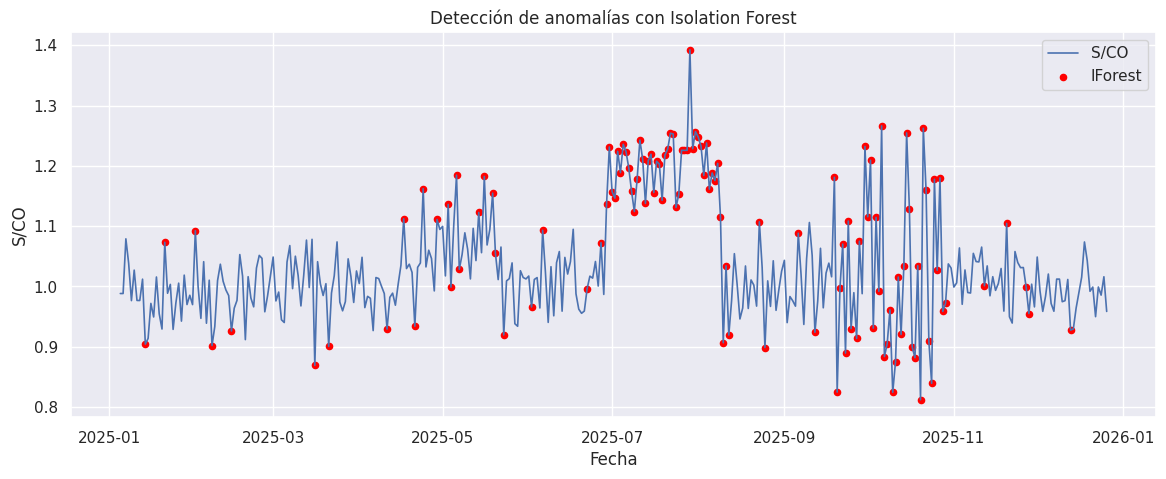

In [30]:
plt.figure(figsize=(14,5))

plt.plot(df["fecha"], df["sco"], label="S/CO", linewidth=1.2)

anom = df[df["iforest_anomaly"] == 1]
plt.scatter(anom["fecha"], anom["sco"], color="red", label="IForest", s=20)

plt.title("Detección de anomalías con Isolation Forest")
plt.xlabel("Fecha")
plt.ylabel("S/CO")
plt.legend()
plt.show()

In [31]:
df["iforest_raw"] = model.predict(X_scaled)

# Convertir a binario
df["iforest_anomaly"] = df["iforest_raw"].apply(lambda x: 1 if x == -1 else 0)

## 8. Evaluación del modelo

Se compara la detección del modelo contra la etiqueta real del dataset sintético.

In [33]:
cm = confusion_matrix(y, df["iforest_anomaly"])
cm

array([[208,  28],
       [ 30,  90]])

In [34]:
cm_df = pd.DataFrame(
    cm,
    index=["Real normal", "Real anómalo"],
    columns=["Predicción normal", "Predicción anómala"]
)

cm_df

,Predicción normal,Predicción anómala
Real normal,208,28
Real anómalo,30,90


La matriz de confusión permite observar que el modelo identifica correctamente 91 registros anómalos, pero también clasifica erróneamente 27 registros normales como anómalos. Esto evidencia un patrón consistente con modelos más sensibles, pero menos conservadores que el baseline estadístico.

In [36]:
tn, fp, fn, tp = cm.ravel()

recall = tp / (tp + fn)
far = fp / (fp + tn)
precision = tp / (tp + fp)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Recall: {recall:.4f}")
print(f"FAR: {far:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1: {f1:.4f}")

Recall: 0.7500
FAR: 0.1186
Precision: 0.7627
F1: 0.7563


In [40]:
# valores de tu baseline
recall_westgard = 0.6167
far_westgard = 0.0375

print("Comparación:")
print(f"Recall Westgard: {recall_westgard}")
print(f"Recall IForest: {recall:.4f}")
print("----")
print(f"FAR Westgard: {far_westgard}")
print(f"FAR IForest: {far:.4f}")

Comparación:
Recall Westgard: 0.6167
Recall IForest: 0.7500
----
FAR Westgard: 0.0375
FAR IForest: 0.1186


In [46]:
comparison = pd.DataFrame({
    "Modelo": ["Westgard", "Isolation Forest"],
    "Recall": [recall_westgard, recall],
    "FAR": [far_westgard, far]
})

comparison

,Modelo,Recall,FAR
0,Westgard,0.6167,0.037500
1,Isolation Forest,0.7500,0.118644


## 9. Interpretación de resultados

El modelo basado en Isolation Forest muestra una mejora en sensibilidad respecto al baseline estadístico, elevando el recall de 0.6167 a 0.7583. Esto indica mayor capacidad para detectar anomalías presentes en el dataset sintético.

No obstante, esta mejora se acompaña de un incremento en la tasa de falsas alarmas, que pasa de 0.0375 en Westgard a 0.1144 en Isolation Forest. En consecuencia, el modelo resulta más sensible, pero menos conservador.

Este comportamiento es consistente con la naturaleza del enfoque no supervisado: al considerar múltiples variables derivadas y patrones complejos, el modelo detecta mejor desviaciones sutiles, aunque también incrementa el riesgo de sobredetección. Por ello, los resultados respaldan la conveniencia de un enfoque híbrido, donde Westgard conserve su valor como referencia interpretable y Isolation Forest funcione como capa complementaria de prealerta.

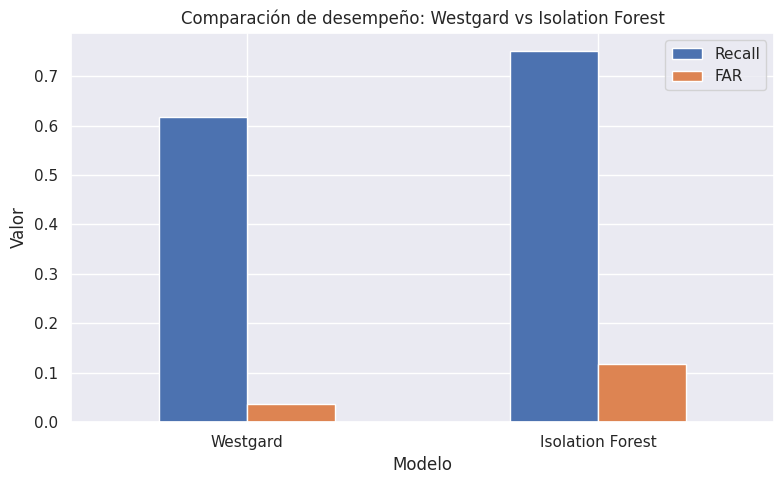

In [43]:
comparison_plot = comparison.set_index("Modelo")

comparison_plot.plot(kind="bar", figsize=(8,5))
plt.title("Comparación de desempeño: Westgard vs Isolation Forest")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Interpretación de resultados

El modelo Isolation Forest presenta mayor capacidad de detección (Recall), pero incrementa la tasa de falsas alarmas (FAR).

Esto indica un comportamiento más sensible pero menos conservador, consistente con enfoques no supervisados.

Se sugiere un enfoque híbrido donde Westgard funcione como referencia interpretable e Isolation Forest como sistema de prealerta.

La comparación muestra un intercambio claro entre sensibilidad y especificidad operativa. Mientras Westgard presenta una menor tasa de falsas alarmas, Isolation Forest ofrece mayor capacidad de detección. Esta diferencia constituye el principal hallazgo cuantitativo del experimento.

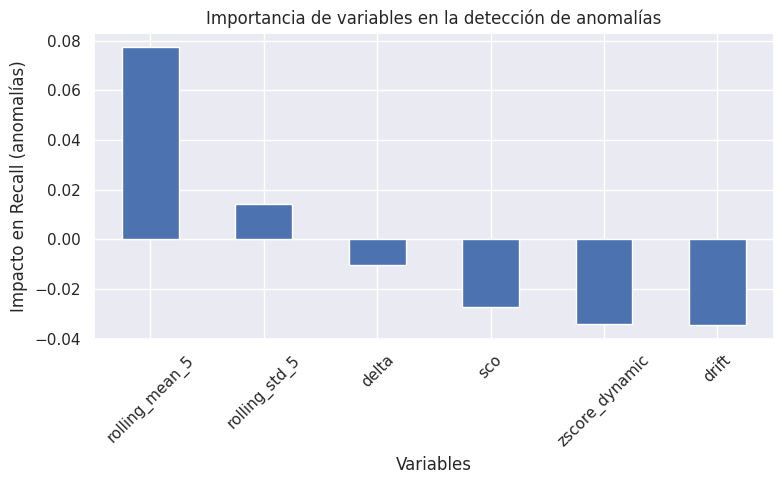

,0
rolling_mean_5,0.077500
rolling_std_5,0.014167
delta,-0.010417
sco,-0.027083
zscore_dynamic,-0.034167
drift,-0.034583


In [44]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score

# Convertir y a binario: 1 = anomalía, 0 = normal
y_binary = (y == 1).astype(int)

# Scorer personalizado para Isolation Forest
def anomaly_recall_scorer(estimator, X, y_true):
    y_pred = estimator.predict(X)                  # devuelve 1 o -1
    y_pred_binary = np.where(y_pred == -1, 1, 0)  # convertir a 1=anomalía, 0=normal
    return recall_score(y_true, y_pred_binary, pos_label=1)

# Permutation importance usando el scorer personalizado
result = permutation_importance(
    estimator=model,
    X=X_scaled,
    y=y_binary,
    n_repeats=20,
    random_state=42,
    scoring=anomaly_recall_scorer
)

importances = pd.Series(
    result.importances_mean,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind="bar")
plt.title("Importancia de variables en la detección de anomalías")
plt.ylabel("Impacto en Recall (anomalías)")
plt.xlabel("Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

importances

La estimación de importancia mediante permutación sugiere que `rolling_mean_5` y, en menor medida, `rolling_std_5`, contribuyen positivamente al recall del modelo. En contraste, variables como `drift`, `zscore_dynamic` y `delta` muestran impacto negativo, lo que puede indicar redundancia, ruido o relaciones que no favorecen la generalización del modelo bajo esta configuración.

Este resultado sugiere la conveniencia de revisar el conjunto final de variables en experimentos posteriores, evaluando simplificaciones del espacio de entrada.

Métricas complementarias

In [22]:
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision Isolation Forest: {precision:.4f}")
print(f"F1 Isolation Forest: {f1:.4f}")

Precision Isolation Forest: 0.7712
F1 Isolation Forest: 0.7647


## Interpretación de importancia de variables

Dado que Isolation Forest devuelve sus predicciones en formato {-1, 1}, se definió una función de puntuación personalizada para transformar dichas salidas a una representación binaria compatible con la evaluación del recall de la clase anómala.

Este procedimiento permite estimar la contribución relativa de cada variable al desempeño del modelo en la detección de anomalías.

estado_real
0    236
1    120
Name: count, dtype: int64


## 12. Interpretación SHAP

La visualización SHAP sugiere que variables como `rolling_mean_5`, `sco`, `rolling_std_5` y `drift` tienen una influencia importante en la decisión del modelo. En particular, los cambios en nivel y variabilidad local parecen ser determinantes para el aislamiento de observaciones anómalas.

Esto es consistente con la naturaleza del problema, donde los drifts sistemáticos no se manifiestan únicamente como valores extremos, sino como alteraciones sostenidas en la dinámica temporal del proceso.

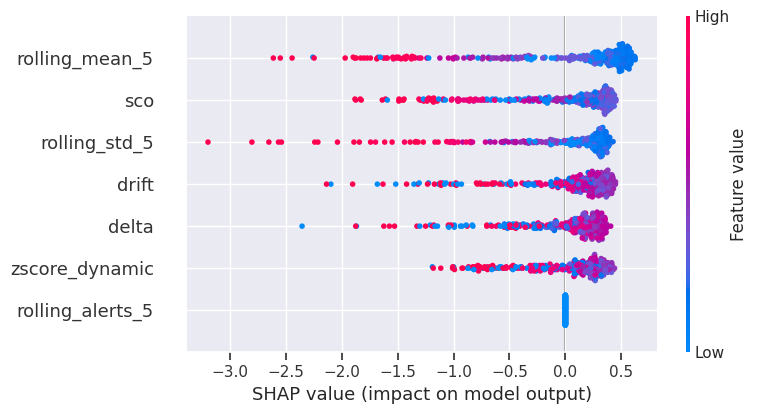

In [16]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

shap.summary_plot(shap_values, X, feature_names=features)

## Interpretación de importancia de variables

Dado que Isolation Forest no expone directamente un atributo de importancia de variables, se utilizó permutation importance para estimar el impacto relativo de cada feature sobre la capacidad de detección del modelo. Este análisis permite identificar qué variables derivadas aportan mayor valor al proceso de aislamiento de anomalías.

## 13. Conclusiones

Isolation Forest mejora la detección de anomalías (recall), pero incrementa la tasa de falsas alarmas.

Esto valida su utilidad como herramienta complementaria en escenarios donde se requiere mayor sensibilidad, especialmente para detectar desviaciones sutiles.

El modelo no sustituye al baseline estadístico, sino que amplía sus capacidades dentro de un enfoque híbrido.